# Makemore Lesson 03

Live notes and code while following Andrej Karpathy's makemore Part 3.

## Session Goals

- Follow the lesson actively.
- Keep code runnable.
- Add short notes only when a concept is confusing or important.

## 复习前的三个卡住点（来自 Part 2 Session Log）

在看 Part 3 之前，先确认这三个问题清楚了：
1. **滑动窗口**：`context = context[1:] + [ix]`，左边扔掉，右边加新字符
2. **block_size 改动的维度链**：只影响 flatten 后的维度 → 只有 W1 第一个维度变
3. **bigram 不如 MLP**：context 更长 + embedding 泛化能力更强

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## Data

In [2]:
words = open('../data/names.txt', 'r').read().splitlines()
words[:8], len(words)

(['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia'],
 32033)

## Notes

- 

## Vocab & Dataset

In [3]:
# build vocab
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print('vocab_size:', vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
vocab_size: 27


In [4]:
# build dataset
block_size = 3

def build_dataset(words):
  X, Y = [], []
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])   # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte,  Yte  = build_dataset(words[n2:])   # 10%
print(Xtr.shape, Xdev.shape, Xte.shape)

torch.Size([182625, 3]) torch.Size([22655, 3]) torch.Size([22866, 3])


## MLP (Part 2 清理版 / Part 3 起点)

In [9]:
# 超参数用变量名，不再写死数字
n_embd  = 10  # embedding 维度
n_hidden = 200 # hidden layer 大小

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd),             generator=g)
W1 = torch.randn((n_embd * block_size, n_hidden),  generator=g)
b1 = torch.randn(n_hidden,                         generator=g)

W2 = torch.randn((n_hidden, vocab_size),            generator=g) * 0.1
b2 = torch.randn(vocab_size,                        generator=g) * 0  
# the first chas' logits should be around zero and uniform
# hockey stick 是初始化问题的症状，不是正常现象。 看到它就说明你的网络在训练开始时处于一个很差的状态

parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [12]:
# loop
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

  # minibatch
  ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
  Xb, Yb = Xtr[ix], Ytr[ix]

  # forward pass
  emb = C[Xb]                        # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1          # hidden layer pre-activation
  h = torch.tanh(hpreact)             # hidden layer
  logits = h @ W2 + b2                # output layer
  loss = F.cross_entropy(logits, Yb)

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # log
  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())

      0/ 200000: 3.7645
  10000/ 200000: 1.8999
  20000/ 200000: 1.9214
  30000/ 200000: 2.0700
  40000/ 200000: 2.1397
  50000/ 200000: 2.1427
  60000/ 200000: 2.1501
  70000/ 200000: 2.7582
  80000/ 200000: 2.5604
  90000/ 200000: 2.4134
 100000/ 200000: 2.2407
 110000/ 200000: 1.8735
 120000/ 200000: 2.1818
 130000/ 200000: 1.9365
 140000/ 200000: 1.8367
 150000/ 200000: 2.4308
 160000/ 200000: 2.1813
 170000/ 200000: 1.7522
 180000/ 200000: 1.9250
 190000/ 200000: 2.1931


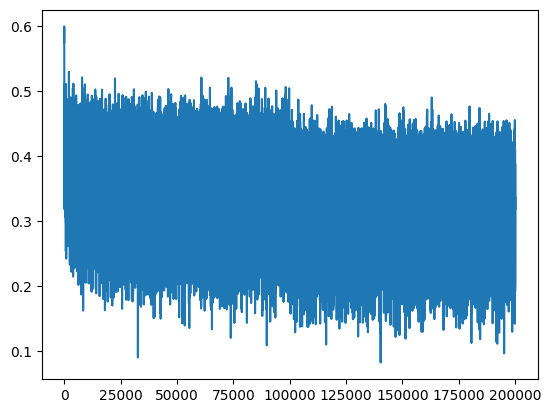

In [13]:
plt.plot(lossi)

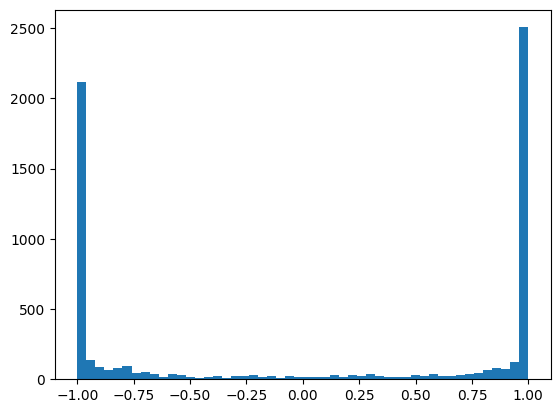

In [15]:
plt.hist(h.view(-1).tolist(), 50);

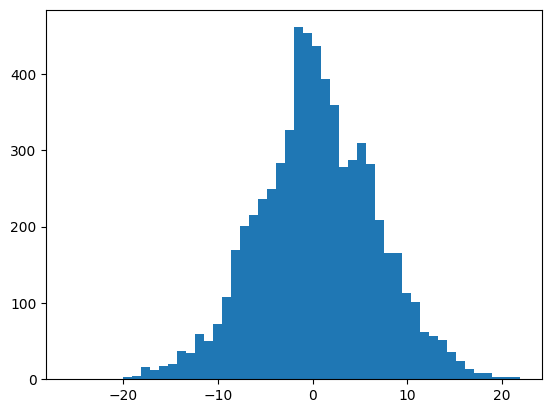

In [16]:
plt.hist(hpreact.view(-1).tolist(), 50);

In [ ]:
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr,  Ytr),
    'val':   (Xdev, Ydev),
    'test':  (Xte,  Yte),
  }[split]
  emb = C[x]                          # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1)    # (N, n_hidden)
  logits = h @ W2 + b2                 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

## Notes

- 

---

## Activation Functions & tanh 饱和问题

![activation functions](../docs/assets/activation_functions.png)

---

### tanh 的 backward

forward：
```
t = tanh(x)
```

backward（链式法则）：
```
x.grad = out.grad * (1 - t²)   ← local gradient
```

| t 的值 | local gradient `(1 - t²)` | 结果 |
|--------|--------------------------|------|
| t = 1  | 1 - 1 = **0** | 梯度归零，backward 断掉 |
| t = -1 | 1 - 1 = **0** | 梯度归零，backward 断掉 |
| t = 0  | 1 - 0 = **1** | 梯度原样通过，最理想 |

---

### 为什么 histogram 两端堆满是糟糕的

- W1 初始化太大 → hpreact 值很大 → tanh 把它们压到 ±1
- ±1 处梯度 = 0 → W1、b1、C 全部学不到东西
- 200 个 hidden neurons，大量是死的

Karpathy 原话：
> *"the more you are in the flat tails, the more the gradient is squashed"*

---

### 解决方法

缩小 W1 的初始化，让 hpreact 集中在 0 附近：

```python
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * 0.2
# 默认是 * 1，太大了
```

这样 tanh 输入小，输出集中在 0，`(1 - t²)` 接近 1，梯度正常流动。